In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the CSV Files

customers = pd.read_csv("zomato_customers.csv")
restaurants = pd.read_csv("zomato_restaurants.csv")
partners = pd.read_csv("zomato_partners.csv")
promotions = pd.read_csv("zomato_promotions.csv")
orders = pd.read_csv("zomato_orders.csv")

In [3]:
#Explore the Data
#First 5 rows

customers.head()

,Customer_ID,Customer_Name,City,Membership,Age
0,10001,Customer 1,Bengaluru,Silver,43
1,10002,Customer 2,Mumbai,Gold,52
2,10003,Customer 3,Pune,NaN,55
3,10004,Customer 4,Mumbai,Silver,20
4,10005,Customer 5,Pune,gold,44


In [4]:
orders.head()

,Order_ID,Customer_ID,Restaurant_ID,Partner_ID,Promo_ID,Order_Date,Order_Status,Payment_Method,Order_Amount,Delivery_Time_Min,Delivery_Rating
0,50001,10079,20189,30133,40001,2025-03-25,Cancelled,Card,990.35,35,3
1,50002,10766,20006,30005,40001,2024-12-28,Pending,Card,739.61,63,1
2,50003,10271,20143,30091,40002,2025-08-01,delivered,Cash,2693.23,55,3
3,50004,10708,20091,30108,40001,2025-12-31,Cancelled,Wallet,444.20,23,3
4,50005,10373,20200,30121,40004,2024-03-25,Cancelled,Cash,448.64,50,4


In [5]:
#Shape

orders.shape

(5000, 11)

In [6]:
#Data Types

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           5000 non-null   int64  
 1   Customer_ID        5000 non-null   int64  
 2   Restaurant_ID      5000 non-null   int64  
 3   Partner_ID         5000 non-null   int64  
 4   Promo_ID           5000 non-null   int64  
 5   Order_Date         5000 non-null   object 
 6   Order_Status       5000 non-null   object 
 7   Payment_Method     5000 non-null   object 
 8   Order_Amount       4956 non-null   float64
 9   Delivery_Time_Min  5000 non-null   int64  
 10  Delivery_Rating    5000 non-null   int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 429.8+ KB


In [7]:
#Summary Statistics

orders.describe()

,Order_ID,Customer_ID,Restaurant_ID,Partner_ID,Promo_ID,Order_Amount,Delivery_Time_Min,Delivery_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,4956.000000,5000.000000,5000.000000
mean,52500.500000,10502.473600,20100.493400,30075.563200,40003.00380,1649.783618,50.650200,2.990200
std,1443.520003,287.816709,57.105294,43.702549,1.41088,891.250100,22.992076,1.422009
min,50001.000000,10001.000000,20001.000000,30001.000000,40001.00000,120.200000,10.000000,1.000000
25%,51250.750000,10256.750000,20052.000000,30037.750000,40002.00000,860.522500,31.000000,2.000000
50%,52500.500000,10508.000000,20102.000000,30076.000000,40003.00000,1649.935000,51.000000,3.000000
75%,53750.250000,10745.000000,20150.000000,30113.000000,40004.00000,2423.465000,70.000000,4.000000
max,55000.000000,11000.000000,20200.000000,30150.000000,40005.00000,3199.840000,90.000000,5.000000


In [8]:
#Check Missing Values

orders.isnull().sum()

Order_ID              0
Customer_ID           0
Restaurant_ID         0
Partner_ID            0
Promo_ID              0
Order_Date            0
Order_Status          0
Payment_Method        0
Order_Amount         44
Delivery_Time_Min     0
Delivery_Rating       0
dtype: int64

In [9]:
customers.isnull().sum()

Customer_ID        0
Customer_Name      0
City               0
Membership       254
Age                0
dtype: int64

In [10]:
restaurants.isnull().sum()

Restaurant_ID      0
Restaurant_Name    0
Cuisine            0
Category           0
City               0
Rating             5
dtype: int64

In [11]:
partners.isnull().sum()

Partner_ID      0
Partner_Name    0
Vehicle         0
City            0
dtype: int64

In [12]:
promotions.isnull().sum()

Promo_ID      0
Promo_Code    0
Discount      0
dtype: int64

In [13]:
#Find Duplicate Records

orders.duplicated().sum()

np.int64(0)

In [14]:
#Remove duplicates

orders.drop_duplicates(inplace=True)

In [15]:
customers.duplicated().sum()

np.int64(0)

In [16]:
restaurants.duplicated().sum()

np.int64(0)

In [17]:
partners.duplicated().sum()

np.int64(0)

In [18]:
promotions.duplicated().sum()

np.int64(0)

In [19]:
#Data Cleaning
#Remove extra spaces

customers["Customer_Name"] = customers["Customer_Name"].str.strip()

In [20]:
#Standardize Membership

customers["Membership"] = customers["Membership"].str.title()

In [21]:
#Standardize City

customers["City"] = customers["City"].str.title()

In [22]:
#Standardize Order Status

orders["Order_Status"] = orders["Order_Status"].str.title()

In [23]:
#Convert Data Types

orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])

In [24]:
#Merge Tables

df = orders.merge(customers,on="Customer_ID")

In [25]:
df = df.merge(restaurants,on="Restaurant_ID")

In [26]:
df = df.merge(partners,on="Partner_ID")

In [27]:
df = df.merge(promotions,on="Promo_ID")

In [28]:
#Basic Analysis
#Total Orders

df["Order_ID"].count()

np.int64(5000)

In [29]:
#Total Revenue

df["Order_Amount"].sum()

np.float64(8176327.61)

In [30]:
#Average Order Value

df["Order_Amount"].mean()

np.float64(1649.7836178369653)

In [31]:
#Highest Order

df["Order_Amount"].max()

3199.84

In [32]:
#Lowest Order

df["Order_Amount"].min()

120.2

In [33]:
#Top 10 Customers

df.groupby("Customer_Name")["Order_Amount"].sum().sort_values(ascending=False).head(10)

Customer_Name
Customer 179    23340.27
Customer 735    22810.96
Customer 718    21717.08
Customer 781    21492.81
Customer 672    21258.54
Customer 878    20781.59
Customer 848    20701.35
Customer 631    20678.25
Customer 308    20557.21
Customer 564    20247.67
Name: Order_Amount, dtype: float64

In [34]:
#Top Restaurants

df.groupby("Restaurant_Name")["Order_Amount"].sum().sort_values(ascending=False).head(10)

Restaurant_Name
Restaurant 151    73665.81
Restaurant 30     64865.47
Restaurant 104    61195.96
Restaurant 128    60047.02
Restaurant 103    59326.18
Restaurant 171    58239.87
Restaurant 120    56925.33
Restaurant 38     56906.54
Restaurant 49     56399.63
Restaurant 15     55619.40
Name: Order_Amount, dtype: float64

In [35]:
#Orders by City

df.groupby("City_x")["Order_ID"].count()

City_x
Bengaluru    582
Delhi        558
Hyderabad    622
Mumbai       713
Nagpur       604
Nashik       692
Pune         634
Thane        595
Name: Order_ID, dtype: int64

In [36]:
#Revenue by Cuisine

df.groupby("Cuisine")["Order_Amount"].sum()

Cuisine
Biryani         1020887.80
Cafe             771611.73
Chinese          959124.52
Desserts        1019288.02
Fast Food       1168639.90
Italian         1323994.94
North Indian    1028868.29
South Indian     883912.41
Name: Order_Amount, dtype: float64

In [37]:
#Revenue by Payment Method

df.groupby("Payment_Method")["Order_Amount"].sum()

Payment_Method
Card      2118653.04
Cash      2029946.09
UPI       2042906.25
Wallet    1984822.23
Name: Order_Amount, dtype: float64

In [38]:
#Orders by Status

df["Order_Status"].value_counts()

Order_Status
Delivered    1986
Cancelled    1049
Pending       995
Refunded      970
Name: count, dtype: int64

In [39]:
#Monthly Analysis
#Extract Month

df["Month"] = df["Order_Date"].dt.month_name()

In [40]:
#Orders per month

df.groupby("Month")["Order_ID"].count()

Month
April        411
August       436
December     459
February     375
January      433
July         446
June         400
March        426
May          408
November     388
October      427
September    391
Name: Order_ID, dtype: int64

In [41]:
#Revenue per month

df.groupby("Month")["Order_Amount"].sum()

Month
April        694593.50
August       690570.88
December     742194.55
February     635875.33
January      718885.00
July         730842.29
June         641011.09
March        691886.58
May          666903.35
November     613380.78
October      690714.74
September    659469.52
Name: Order_Amount, dtype: float64

In [42]:
#Top Rated Restaurants

restaurants.sort_values("Rating",ascending=False).head(10)

,Restaurant_ID,Restaurant_Name,Cuisine,Category,City,Rating
14,20015,Restaurant 15,Biryani,Both,Hyderabad,5.0
68,20069,Restaurant 69,Cafe,Veg,Nagpur,4.9
39,20040,Restaurant 40,Chinese,Veg,Mumbai,4.9
108,20109,Restaurant 109,Fast Food,Both,Bengaluru,4.9
48,20049,Restaurant 49,Italian,Veg,Thane,4.9
111,20112,Restaurant 112,Cafe,Both,Thane,4.9
136,20137,Restaurant 137,Desserts,Both,Nagpur,4.9
166,20167,Restaurant 167,Biryani,Veg,Nagpur,4.9
71,20072,Restaurant 72,Italian,Both,Pune,4.9
0,20001,Restaurant 1,South Indian,Veg,Hyderabad,4.8


In [43]:
#Delivery Performance
#Average Delivery Time

df["Delivery_Time_Min"].mean()

np.float64(50.6502)

In [44]:
#Average Rating

df["Delivery_Rating"].mean()

np.float64(2.9902)

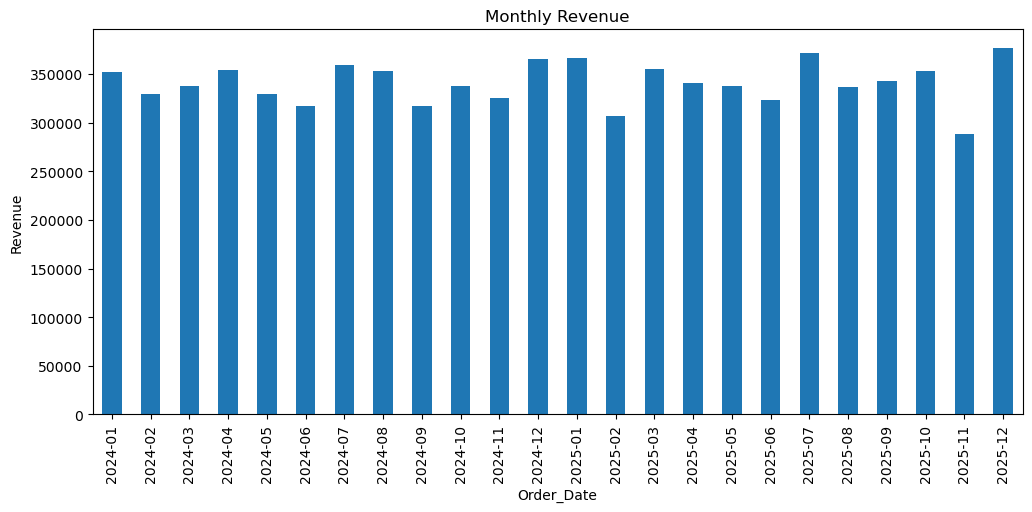

In [45]:
#Visualizations
#Monthly Revenue

monthly = df.groupby(df["Order_Date"].dt.to_period("M"))["Order_Amount"].sum()

monthly.plot(kind="bar", figsize=(12,5))

plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.show()

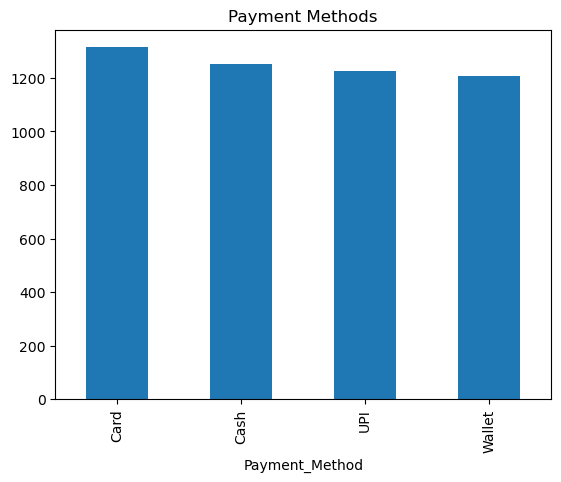

In [46]:
#Payment Method Distribution

df["Payment_Method"].value_counts().plot(kind="bar")

plt.title("Payment Methods")

plt.show()

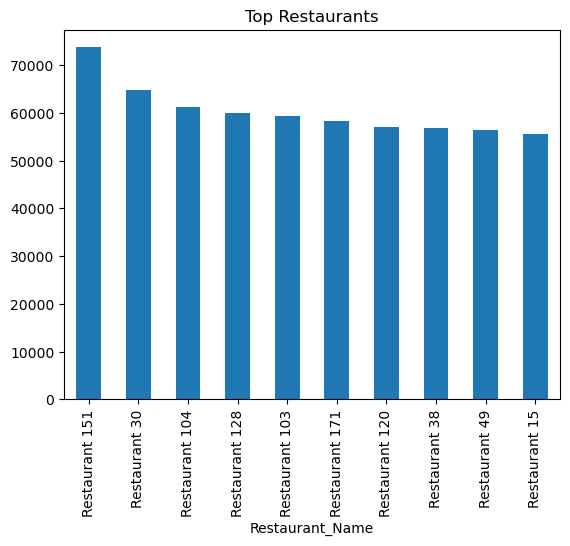

In [47]:
#Top Restaurants

top = df.groupby("Restaurant_Name")["Order_Amount"].sum().nlargest(10)

top.plot(kind="bar")

plt.title("Top Restaurants")

plt.show()

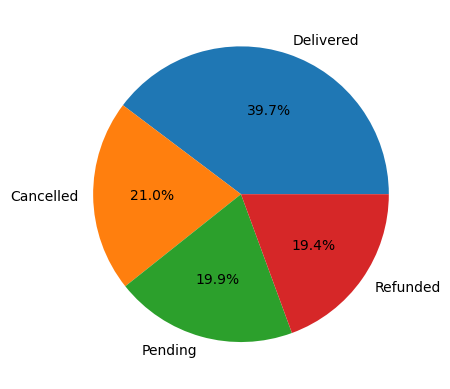

In [48]:
#Order Status

df["Order_Status"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")

plt.show()